In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots show inline in the notebook
%matplotlib inline

# Optional — makes plots look cleaner
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/data/processed/diabetes_cleaned.csv')
df.head()

,encounter_id,patient_number,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetes_med,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,African American,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df['race'] = df['race'].str.replace('AfricanAmerican', 'African American', regex=False)

# Confirm
df['race'].value_counts()

race
Caucasian           76099
African American    19210
Unknown              2273
Hispanic             2037
Other                1506
Asian                 641
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)
Goal: Understand distributions, spot patterns, and identify 
features that may influence patient readmission.

In [4]:
df.to_csv('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/data/processed/diabetes_cleaned.csv', index=False)
print("Saved.")

Saved.


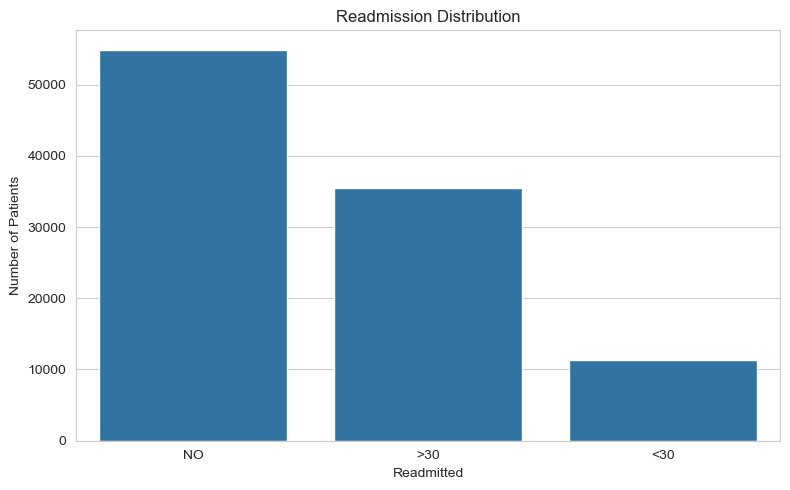

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='readmitted', order=df['readmitted'].value_counts().index)
plt.title('Readmission Distribution')
plt.xlabel('Readmitted')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/charts/readmission_distribution.png')
plt.show()

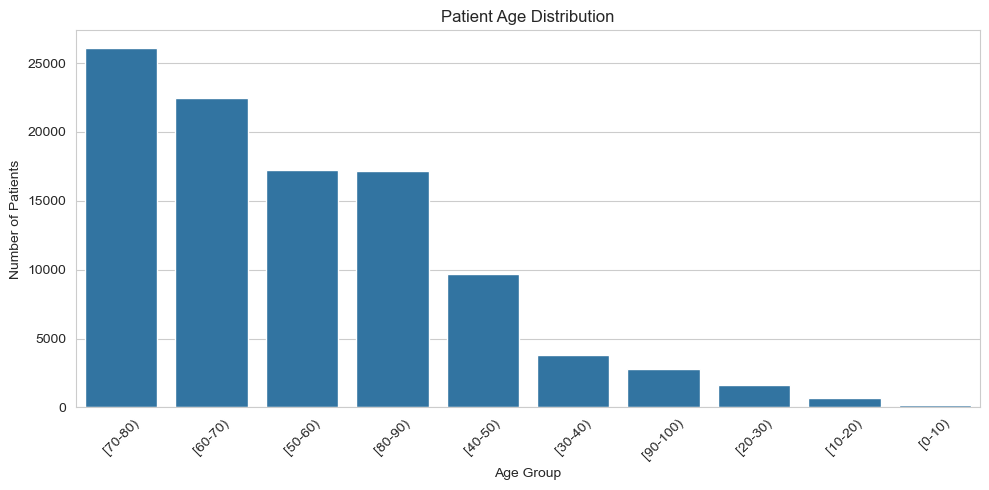

In [6]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='age', order=df['age'].value_counts().index)
plt.title('Patient Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/chartsreadmission_distribution.png')
plt.show()

### Note — Age Distribution Fix
Initial `countplot` ordered age groups by frequency (most to least patients) 
instead of natural age sequence, making the chart misleading and hard to read.

**Fix:** Explicitly defined `age_order` list to force chronological ordering 
left to right `[0-10)` through `[90-100)`.

This is important for a healthcare dataset where age progression is clinically 
meaningful — a chart jumping from `[80-90)` to `[40-50)` misrepresents the 
patient population at a glance.

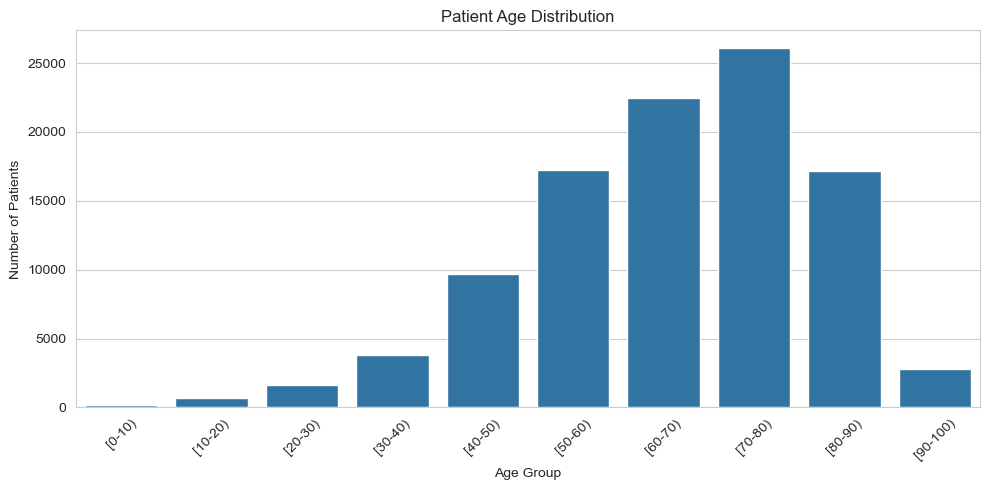

In [7]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='age', order=age_order)
plt.title('Patient Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/charts/readmission_distribution.png')
plt.show()

### Age Distribution Observations
- Peak age group: `[70-80)` — highest number of hospital encounters
- Distribution is skewed toward older patients (50-90 range dominates)
- Very few encounters in younger age groups (0-40)

**Clinical insight:** Older patients likely have more complex health conditions,
multiple medications, and higher readmission risk — age will likely be a strong
predictor in our model.

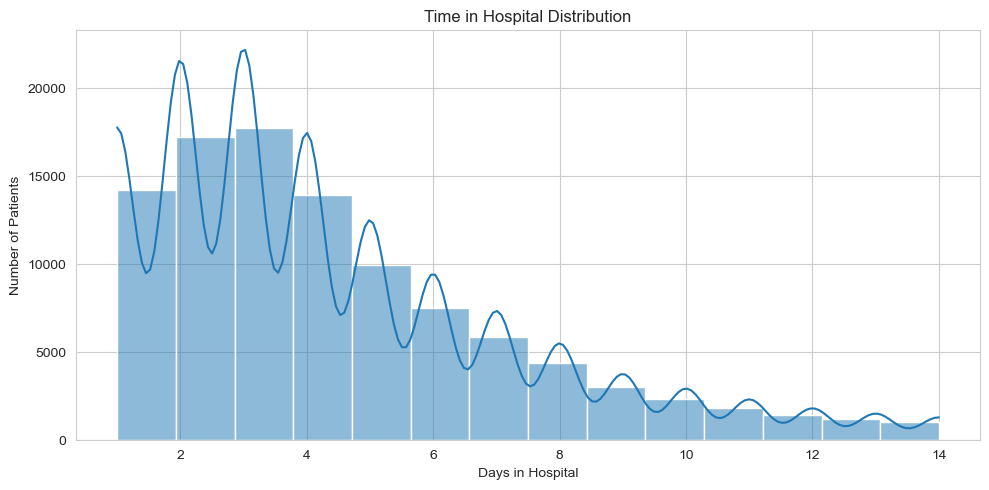

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='time_in_hospital', bins=14, kde=True)
plt.title('Time in Hospital Distribution')
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/charts/time_in_hospital_distribution.png')
plt.show()

### Time in Hospital Observations
- Distribution is right skewed — majority of patients stay 1-4 days
- Long tail extends toward longer stays (up to 14 days)
- Most common stay: ~3 days

**Insight:** Short hospital stays dominate, but patients with longer stays 
may indicate more severe conditions and could be higher readmission risks.

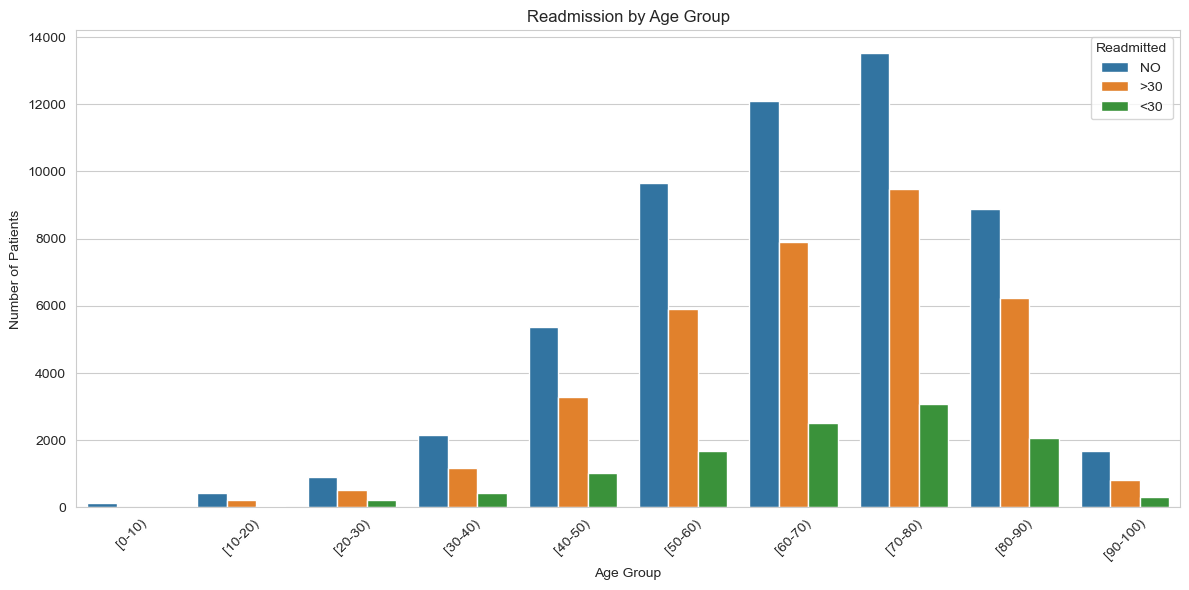

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='age', hue='readmitted', order=age_order)
plt.title('Readmission by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Readmitted')
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/charts/readmission_by_age.png')
plt.show()

### Readmission by Age Group Observations
- `[70-80)` dominates across all three readmission classes
- Older patients (50-90 range) show the highest readmission counts overall
- `<30` readmissions are consistently the smallest bar across every age group
  confirming the class imbalance is present throughout, not just overall

**Insight:** Age is likely a strong predictor for readmission risk.
Older patients not only visit more but also get readmitted more.
The class imbalance in `<30` will need to be addressed during modeling
on Day 9 — likely with SMOTE or class weighting.

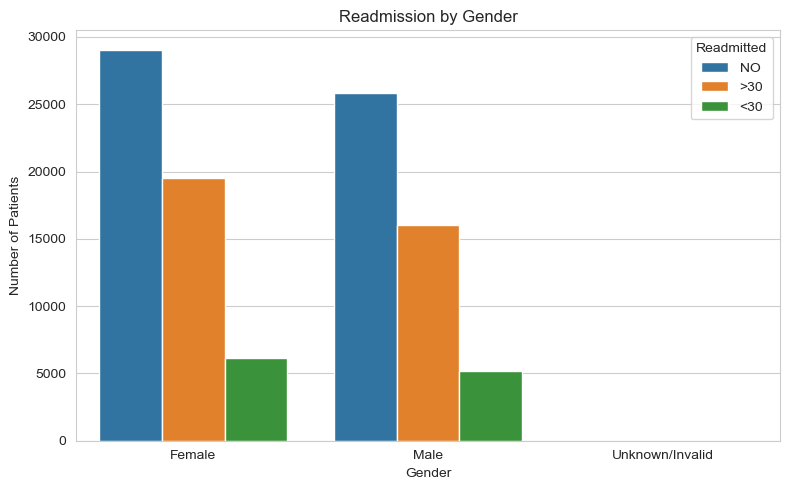

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender', hue='readmitted')
plt.title('Readmission by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.legend(title='Readmitted')
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/charts/readmission_by_gender.png')
plt.show()

### Readmission by Gender Observations
- Female patients had higher readmission counts across all three classes
- This aligns with the overall higher female representation in the dataset
- Gender alone may not be a strong standalone predictor but combined 
  with age and other features could contribute to the model

**Insight:** The difference may reflect that more female patients are 
in the dataset overall rather than females having a higher readmission 
*rate* — worth investigating the proportion later in deeper EDA on Day 6.

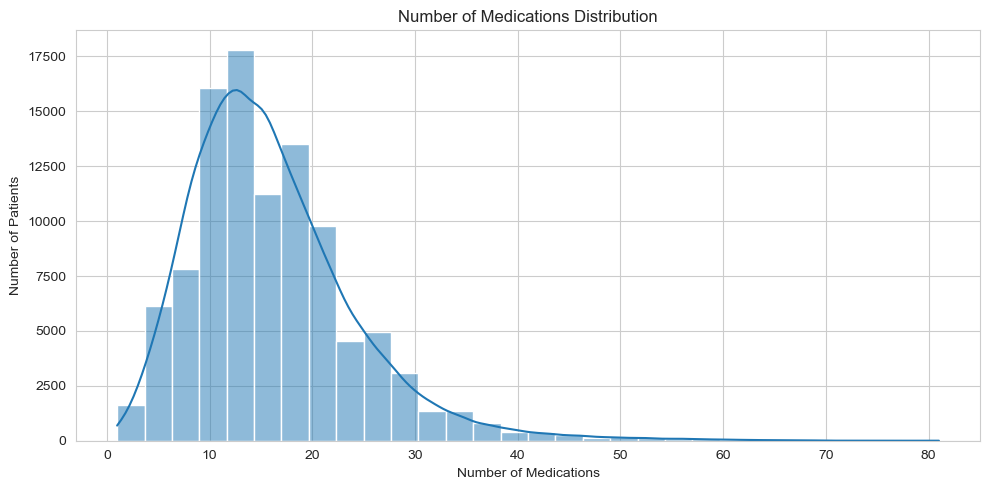

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='num_medications', bins=30, kde=True)
plt.title('Number of Medications Distribution')
plt.xlabel('Number of Medications')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/charts/num_medications_distribution.png')
plt.show()

### Number of Medications Observations
- Distribution peaks around 14 medications per patient
- Distribution appears roughly normal with a slight right skew
- Range spans from 1 to 80+ medications

**Insight:** High medication counts may correlate with more complex 
health conditions which could be a strong predictor for readmission risk.
Patients on more medications likely have more comorbidities.

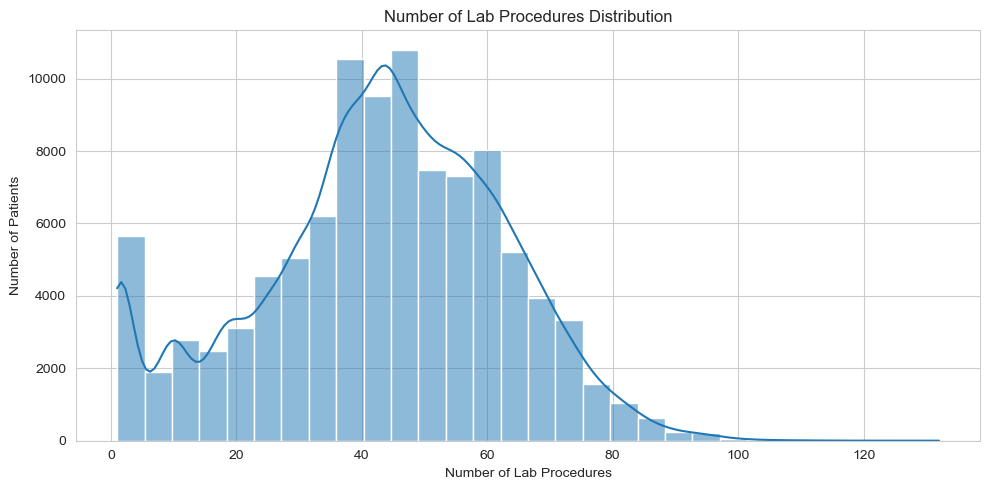

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='num_lab_procedures', bins=30, kde=True)
plt.title('Number of Lab Procedures Distribution')
plt.xlabel('Number of Lab Procedures')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/charts/num_lab_procedures_distribution.png')
plt.show()

### Number of Lab Procedures Observations
- Distribution peaks around 50 lab procedures per patient
- Distribution appears roughly normal
- Range is wide — some patients have very few, others have 100+

**Insight:** Higher lab procedure counts may indicate more intensive 
monitoring during the hospital stay. Could correlate with longer stays 
and potentially higher readmission risk.

## Day 5 Summary
- Created 6 exploratory charts covering distributions and basic relationships
- Key findings:
  - `[70-80)` is the dominant age group
  - Dataset is right skewed for time in hospital (~3 days most common)
  - Female patients have higher raw readmission counts
  - Medication count peaks around 14 per patient
  - Lab procedures peak around 50 per patient
  - Class imbalance confirmed — `<30` readmissions are the minority class
- All charts saved to `outputs/charts/`
- Ready for deeper EDA on Day 6